In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import torch.optim as optim
import time

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [2]:
# Cell 2 - Load KMNIST
transform = transforms.ToTensor()

train_dataset = datasets.KMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.KMNIST(root='./data', train=False, download=True, transform=transform)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

100%|██████████| 18.2M/18.2M [00:20<00:00, 868kB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 186kB/s]
100%|██████████| 3.04M/3.04M [00:03<00:00, 1.00MB/s]
100%|██████████| 5.12k/5.12k [00:00<00:00, 11.8MB/s]

Training samples: 60000
Test samples: 10000


In [3]:
# Cell 3 - Model Architecture
class FeedforwardNN(nn.Module):
    def __init__(self):
        super(FeedforwardNN, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),           # 28x28 → 784
            nn.Linear(784, 128),    # Hidden 1
            nn.ReLU(),
            nn.Linear(128, 64),     # Hidden 2
            nn.ReLU(),
            nn.Linear(64, 10)       # Output (no Softmax)
        )

    def forward(self, x):
        return self.network(x)

# Quick sanity check
model = FeedforwardNN()
print(model)

FeedforwardNN(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


The optimizer is the algorithm that decides how to adjust the weights. AdamW specifically does this adaptively — it gives each weight its own learning rate, and applies weight decay directly to the weights to prevent them from growing too large (regularization).

In [4]:
# Cell 4 - Hyperparameter Configurations
configs = [
    {'lr': 0.001,  'weight_decay': 0.01},   # Default
    {'lr': 0.01,   'weight_decay': 0.001},
    {'lr': 0.01,   'weight_decay': 0.1},
    {'lr': 0.0001, 'weight_decay': 0.001},
    {'lr': 0.0001, 'weight_decay': 0.1},
]

In [5]:
# Cell 5 - Training Function
def train_model(model, train_loader, val_loader, optimizer, epochs=20):
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses, val_accuracies = [], [], []

    start_time = time.time()

    for epoch in range(epochs):
        # --- Training Pass ---
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_losses.append(running_loss / len(train_loader))

        # --- Validation Pass ---
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(correct / total)

    training_time = time.time() - start_time

    return train_losses, val_losses, val_accuracies, training_time

In [6]:
# Cell 6 - 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = []

for config in configs:
    print(f"\nConfig: lr={config['lr']}, weight_decay={config['weight_decay']}")
    fold_val_accuracies = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(train_dataset)):
        # Create data loaders for this fold
        train_loader = DataLoader(Subset(train_dataset, train_idx), batch_size=64, shuffle=True)
        val_loader = DataLoader(Subset(train_dataset, val_idx), batch_size=64, shuffle=False)

        # Fresh model and optimizer for each fold
        model = FeedforwardNN()
        optimizer = optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])

        # Train
        _, _, val_accuracies, _ = train_model(model, train_loader, val_loader, optimizer, epochs=20)

        fold_val_accuracies.append(val_accuracies[-1])
        print(f"  Fold {fold+1} Val Accuracy: {val_accuracies[-1]:.4f}")

    mean_acc = np.mean(fold_val_accuracies)
    std_acc = np.std(fold_val_accuracies)
    print(f"  Mean: {mean_acc:.4f} | Std: {std_acc:.4f}")

    cv_results.append({
        'lr': config['lr'],
        'weight_decay': config['weight_decay'],
        'mean_val_acc': mean_acc,
        'std_val_acc': std_acc,
        'fold_accuracies': fold_val_accuracies
    })


Config: lr=0.001, weight_decay=0.01
  Fold 1 Val Accuracy: 0.9490
  Fold 2 Val Accuracy: 0.9514
  Fold 3 Val Accuracy: 0.9498
  Fold 4 Val Accuracy: 0.9507
  Fold 5 Val Accuracy: 0.9449
  Mean: 0.9492 | Std: 0.0023

Config: lr=0.01, weight_decay=0.001
  Fold 1 Val Accuracy: 0.9421
  Fold 2 Val Accuracy: 0.9385
  Fold 3 Val Accuracy: 0.9404
  Fold 4 Val Accuracy: 0.9299
  Fold 5 Val Accuracy: 0.9372
  Mean: 0.9376 | Std: 0.0042

Config: lr=0.01, weight_decay=0.1
  Fold 1 Val Accuracy: 0.9305
  Fold 2 Val Accuracy: 0.9094
  Fold 3 Val Accuracy: 0.9319
  Fold 4 Val Accuracy: 0.9176
  Fold 5 Val Accuracy: 0.9282
  Mean: 0.9235 | Std: 0.0087

Config: lr=0.0001, weight_decay=0.001
  Fold 1 Val Accuracy: 0.9307
  Fold 2 Val Accuracy: 0.9273
  Fold 3 Val Accuracy: 0.9295
  Fold 4 Val Accuracy: 0.9303
  Fold 5 Val Accuracy: 0.9289
  Mean: 0.9294 | Std: 0.0012

Config: lr=0.0001, weight_decay=0.1
  Fold 1 Val Accuracy: 0.9271
  Fold 2 Val Accuracy: 0.9303
  Fold 3 Val Accuracy: 0.9280
  Fold 4 

In [7]:
# Cell 7 - Find Best Config
best_config = max(cv_results, key=lambda x: x['mean_val_acc'])
print(f"Best Config: lr={best_config['lr']}, weight_decay={best_config['weight_decay']}")
print(f"Mean Val Accuracy: {best_config['mean_val_acc']:.4f}")
print(f"Std: {best_config['std_val_acc']:.4f}")

Best Config: lr=0.001, weight_decay=0.01
Mean Val Accuracy: 0.9492
Std: 0.0023


In [8]:
# Cell 8 - Final Model Training
# Full training dataloader (no splits)
full_train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Fresh model with best config
final_model = FeedforwardNN()
final_optimizer = optim.AdamW(final_model.parameters(),
                               lr=best_config['lr'],
                               weight_decay=best_config['weight_decay'])

# Train
train_losses, val_losses, val_accuracies, training_time = train_model(
    final_model, full_train_loader, test_loader, final_optimizer, epochs=20
)

# Evaluate on test set
correct, total = 0, 0
final_model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = final_model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Training Time: {training_time:.2f} seconds")

Test Accuracy: 0.8872
Training Time: 189.64 seconds


/tmp/ipykernel_687/4095545104.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot(fold_accs, labels=labels)


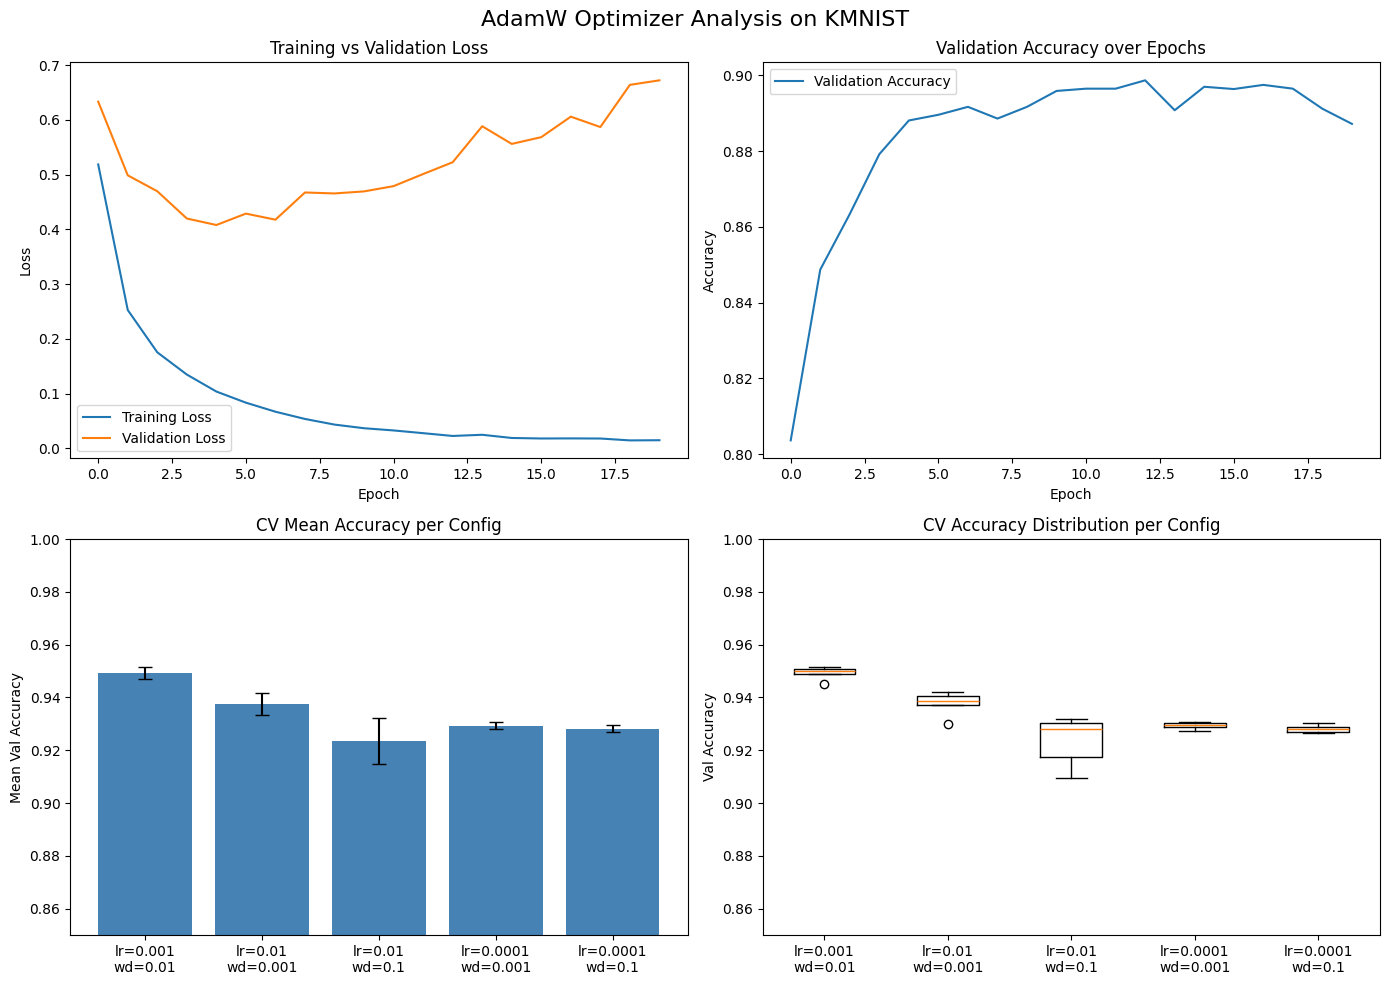

In [9]:
# Cell 9 - Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('AdamW Optimizer Analysis on KMNIST', fontsize=16)

# Plot 1 - Loss Curves
axes[0, 0].plot(train_losses, label='Training Loss')
axes[0, 0].plot(val_losses, label='Validation Loss')
axes[0, 0].set_title('Training vs Validation Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

# Plot 2 - Accuracy Curves
axes[0, 1].plot(val_accuracies, label='Validation Accuracy')
axes[0, 1].set_title('Validation Accuracy over Epochs')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()

# Plot 3 - Bar Chart of CV Mean Accuracy per Config
labels = [f"lr={r['lr']}\nwd={r['weight_decay']}" for r in cv_results]
means = [r['mean_val_acc'] for r in cv_results]
stds = [r['std_val_acc'] for r in cv_results]
axes[1, 0].bar(labels, means, yerr=stds, capsize=5, color='steelblue')
axes[1, 0].set_title('CV Mean Accuracy per Config')
axes[1, 0].set_ylabel('Mean Val Accuracy')
axes[1, 0].set_ylim(0.85, 1.0)

# Plot 4 - Box Plot of CV Accuracy Distribution
fold_accs = [r['fold_accuracies'] for r in cv_results]
axes[1, 1].boxplot(fold_accs, labels=labels)
axes[1, 1].set_title('CV Accuracy Distribution per Config')
axes[1, 1].set_ylabel('Val Accuracy')
axes[1, 1].set_ylim(0.85, 1.0)

plt.tight_layout()
plt.savefig('adamw_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Only Training loss decreasing smoothly.
Accuracy Curve plateaued at epoch 3. According to Bar Chart, Config 1 is the tallest bar. Accoprding to Boxplot, Config 1 has the smallest box. Config 1 produced the best results at lr = 0.001 and wd = 0.01. You run the risk of unstable training and underfitting when the learning rate is too high or too low.